In [72]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier,export_text
from sklearn.metrics import confusion_matrix,classification_report

# Weather Dataset

In [73]:
weather = pd.read_csv('https://gist.githubusercontent.com/bigsnarfdude/515849391ad37fe593997fe0db98afaa/raw/f663366d17b7d05de61a145bbce7b2b961b3b07f/weather.csv')
weather.head()

,outlook,temperature,humidity,windy,play
0,overcast,hot,high,False,yes
1,overcast,cool,normal,True,yes
2,overcast,mild,high,True,yes
3,overcast,hot,normal,False,yes
4,rainy,mild,high,False,yes


## Checking if there are any null instances or not

In [93]:
weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   outlook      14 non-null     object
 1   temperature  14 non-null     object
 2   humidity     14 non-null     object
 3   windy        14 non-null     bool  
 4   play         14 non-null     object
dtypes: bool(1), object(4)
memory usage: 594.0+ bytes


## Separating the class label and features

In [74]:
X = weather.iloc[:,:-1].copy()
y = weather.iloc[:,-1].copy()

## Distribution of class label

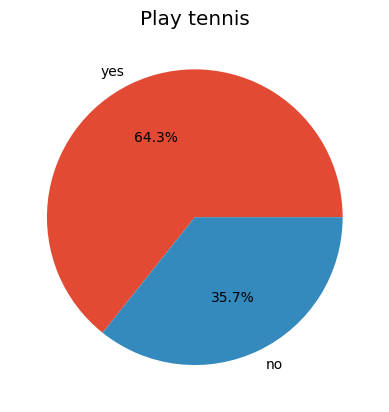

In [75]:
plt.style.use("ggplot")
plt.pie(y.value_counts(),labels=y.value_counts().index,autopct='%1.1f%%')
plt.title("Play tennis")
plt.show()

## Encoding the features

In [76]:
encoder = LabelEncoder()
y_encode = encoder.fit_transform(y)
y = pd.Series(y_encode)
classes = encoder.classes_
classes

array(['no', 'yes'], dtype=object)

In [77]:
X = X.apply(encoder.fit_transform)
X.head()

,outlook,temperature,humidity,windy
0,0,1,0,0
1,0,0,1,1
2,0,2,0,1
3,0,1,1,0
4,1,2,0,0


Splitting the dataset into training and test dataset
  - training dataset size : 80% (11)
  - test dataset size : 20% (3)

In [78]:
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=.2,random_state=0)

## Creating the decision tree classifier for this dataset

In [79]:
dt = DecisionTreeClassifier()
classifier = dt.fit(x_train,y_train)
y_pred = classifier.predict(x_test)
y_pred

array([1, 1, 1])

## Rules
  - R1: outlook <= 1.5 -> class 1
  - R2: outlook > 1.5 & humidity <= 0.5 -> class 0
  - R3: humidity > 0.5 -> class 1

In [80]:
rules = export_text(classifier,feature_names=list(X.columns))
print(rules)

|--- outlook <= 1.50
|   |--- class: 1
|--- outlook >  1.50
|   |--- humidity <= 0.50
|   |   |--- class: 0
|   |--- humidity >  0.50
|   |   |--- class: 1



## Confusion Matrix

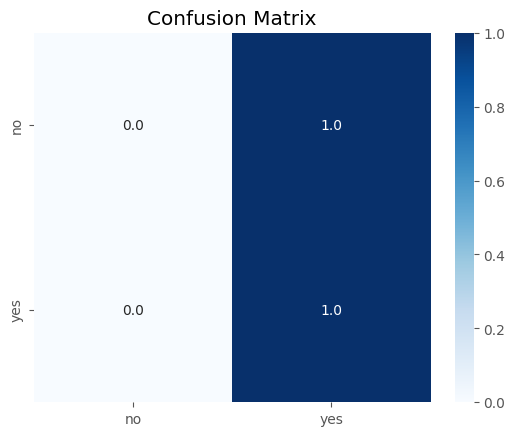

In [81]:
conf_matrix = confusion_matrix(y_pred=y_pred,y_true=y_test,normalize='true')
sns.heatmap(conf_matrix,annot=True,cmap='Blues',xticklabels=classes,yticklabels=classes,fmt=".1f")
plt.title("Confusion Matrix")
plt.show()

# Vertebrate Dataset

In [82]:
vertebrate = pd.read_csv("https://raw.githubusercontent.com/arundhaj/datamining_class/refs/heads/master/data/vertebrate.csv",index_col="Name")
vertebrate.head()

,Body Temperature,Skin Cover,Gives Birth,Aquatic Creature,Aerial Creature,Has Legs,Hibernates,Class Label
Name,,,,,,,,
human,warm-blooded,hair,yes,no,no,yes,no,mammal
python,cold-blooded,scales,no,no,no,no,yes,reptile
salmon,cold-blooded,scales,no,yes,no,no,no,fish
whale,warm-blooded,hair,yes,yes,no,no,no,mammal
frog,cold-blooded,none,no,semi,no,yes,yes,amphibian


## Checking for null instances

In [83]:
vertebrate.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16 entries, human to gila monster
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Body Temperature  16 non-null     object
 1   Skin Cover        16 non-null     object
 2   Gives Birth       16 non-null     object
 3   Aquatic Creature  16 non-null     object
 4   Aerial Creature   16 non-null     object
 5   Has Legs          16 non-null     object
 6   Hibernates        16 non-null     object
 7   Class Label       15 non-null     object
dtypes: object(8)
memory usage: 1.1+ KB


## Dropping NA instance

In [84]:
vertebrate = vertebrate.drop('gila monster',axis="rows")

## Distribution of target

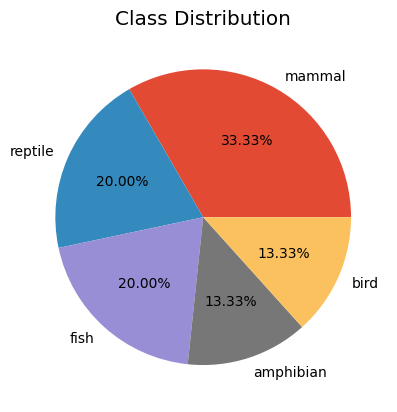

In [85]:
plt.pie(vertebrate['Class Label'].value_counts(dropna=False),labels=vertebrate['Class Label'].value_counts().index,autopct='%.2f%%')
plt.title("Class Distribution")
plt.show()

## Separtating features and target

In [86]:
X = vertebrate.iloc[:,:-1].copy()
y = vertebrate.iloc[:,-1].copy()

## Encoding features

In [87]:
encode = LabelEncoder()
y_encode = encode.fit_transform(y)
y = pd.Series(y_encode)
classes = encode.classes_
classes

array(['amphibian', 'bird', 'fish', 'mammal', 'reptile'], dtype=object)

In [88]:
X = X.apply(encode.fit_transform)
X.head()

,Body Temperature,Skin Cover,Gives Birth,Aquatic Creature,Aerial Creature,Has Legs,Hibernates
Name,,,,,,,
human,1,2,1,0,0,1,0
python,0,5,0,0,0,0,1
salmon,0,5,0,2,0,0,0
whale,1,2,1,2,0,0,0
frog,0,3,0,1,0,1,1


## Splitting the dataset into training & test dataset
  - test dataset size : 20% (3)
  - training dataset size : 80% (12)

In [89]:
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=.2,random_state=0)

## Training the model

In [90]:
dt = DecisionTreeClassifier()
classifier = dt.fit(x_train,y_train)
y_pred = classifier.predict(x_test)
y_pred

array([4, 3, 3])

## Rules
  - R1: Skin Cover <= 4.5 & Gives Birth <= 0.5 & Body Temperature <= 0.5 -> class 0
  - R2: Skin Cover <= 4.5 & Gives Birth <= 0.5 & Body Temperature > 0.5 -> class 1
  - R3: Skin Cover <= 4.5 & Gives Birth > .5 -> class 3
  - R4: Skin Cover > 4.5 & Aquatic Creature <= 1.5 -> class 4
  - R5: Skin Cover > 4.5 & Aquatic Creature > 1.5 -> class 2

In [91]:
rules = export_text(classifier,feature_names=list(X.columns))
print(rules)

|--- Skin Cover <= 4.50
|   |--- Gives Birth <= 0.50
|   |   |--- Body Temperature <= 0.50
|   |   |   |--- class: 0
|   |   |--- Body Temperature >  0.50
|   |   |   |--- class: 1
|   |--- Gives Birth >  0.50
|   |   |--- class: 3
|--- Skin Cover >  4.50
|   |--- Aquatic Creature <= 1.50
|   |   |--- class: 4
|   |--- Aquatic Creature >  1.50
|   |   |--- class: 2



## Confusion Matrix

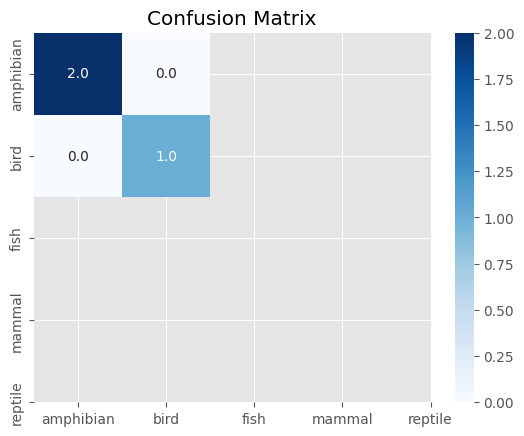

In [92]:
conf_matrix = confusion_matrix(y_pred=y_pred,y_true=y_test)
sns.heatmap(conf_matrix,annot=True,cmap='Blues',xticklabels=classes,yticklabels=classes,fmt=".1f")
plt.title("Confusion Matrix")
plt.show()